This chapter introduces the **complete pipeline for instruction fine-tuning**
of **large language models (LLMs)**.

After implementing and **pretraining an LLM**, and fine-tuning it for a
**classification task**, the focus shifts to adapting the model to
**follow human instructions**.

The chapter covers:
- **Preparing supervised instruction datasets**
- **Organizing instruction data into training batches**
- **Loading pretrained model weights**
- **Fine-tuning the model for instruction following**
- **Evaluating generated instruction responses**

Instruction fine-tuning is a **core technique behind modern chatbots,
personal assistants, and conversational AI systems**.


# Introduction to instruction fine-tuning
During pretraining, an LLM learns to **generate text one word at a time**,
which enables strong **text completion** capabilities.

However, pretrained LLMs often struggle with **explicit human instructions**
such as grammatical correction or sentence transformation.
To address this limitation, the pretrained model is used as the foundation
for **supervised instruction fine-tuning**.

The goal of instruction fine-tuning is to improve the model’s ability to
**understand instructions and generate desired responses**.
A critical component of this process is **dataset preparation**.
This chapter walks through all **three stages of instruction fine-tuning**,
starting with preparing the instruction dataset and continuing through
training and evaluation.


# Preparing a dataset for supervised instruction fine-tuning
This section focuses on **dataset preparation** for **supervised instruction fine-tuning**.
The book uses a small, custom dataset containing **1,100 instruction–response pairs**
(similar to the examples in Figure 7.2). Although created specifically for the book,
other publicly available instruction datasets are referenced in **Appendix B**.

A download function is provided to fetch the dataset as a **204 KB JSON file**.
**JSON (JavaScript Object Notation)** is a lightweight, human-readable format that
closely resembles **Python dictionaries**, making it convenient for data loading
and preprocessing in instruction fine-tuning pipelines.


In [5]:
import json
import os
import urllib
def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:                                               
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()
    with open(file_path, "r") as file:
        data = json.load(file)
    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)
data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


The data list that we loaded from the JSON file contains the 1,100 entries of the
instruction dataset. Let’s print one of the entries to see how each entry is structured:

In [6]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [7]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


<br/>

Instruction fine-tuning trains an LLM using **explicit input–output pairs**,
where both the instruction and the desired response are provided.

These pairs must be formatted into a single textual prompt, commonly referred
to as a **prompt style**. Different LLMs adopt different prompt styles,
as illustrated by models such as **Alpaca** and **Phi-3**.

Alpaca was one of the first models to publicly document its instruction
fine-tuning process and helped establish an early, widely adopted prompt format.
Due to its simplicity and popularity, the **Alpaca prompt style** is used
throughout the rest of this chapter.


In [13]:
def format_input(entry):
    instruction_text = (
                f"Below is an instruction that describes a task. "
                f"Write a response that appropriately completes the request."
                f"\n\n### Instruction:\n{entry['instruction']}"
                        )
   
    input_text = (
                f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
                )
    return instruction_text + input_text

This format_input function takes a dictionary entry as input and constructs a format
ted string. Let’s test it to dataset entry data[50], which we looked at earlier

In [9]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


<br/>

`format_input` **skips the optional `### Input:` section** when the dataset entry has an empty `input` field.
This can be verified by formatting an entry (e.g., `data[999]`) and printing the final prompt
together with the ground-truth output under `### Response:`.

The printed example confirms that entries with no additional input contain only:
**Instruction → Response**, without an `Input` block.

Before building PyTorch dataloaders, the dataset is next split into
**training, validation, and test sets**, similar to the earlier spam-classification workflow.


In [6]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion] 
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## Organizing data into training batches
Since instruction samples
have variable lengths, batching requires a method that ensures the model receives
properly formatted inputs during fine-tuning. This includes constructing batches
efficiently (often via padding and masks) so training can proceed correctly and
consistently.

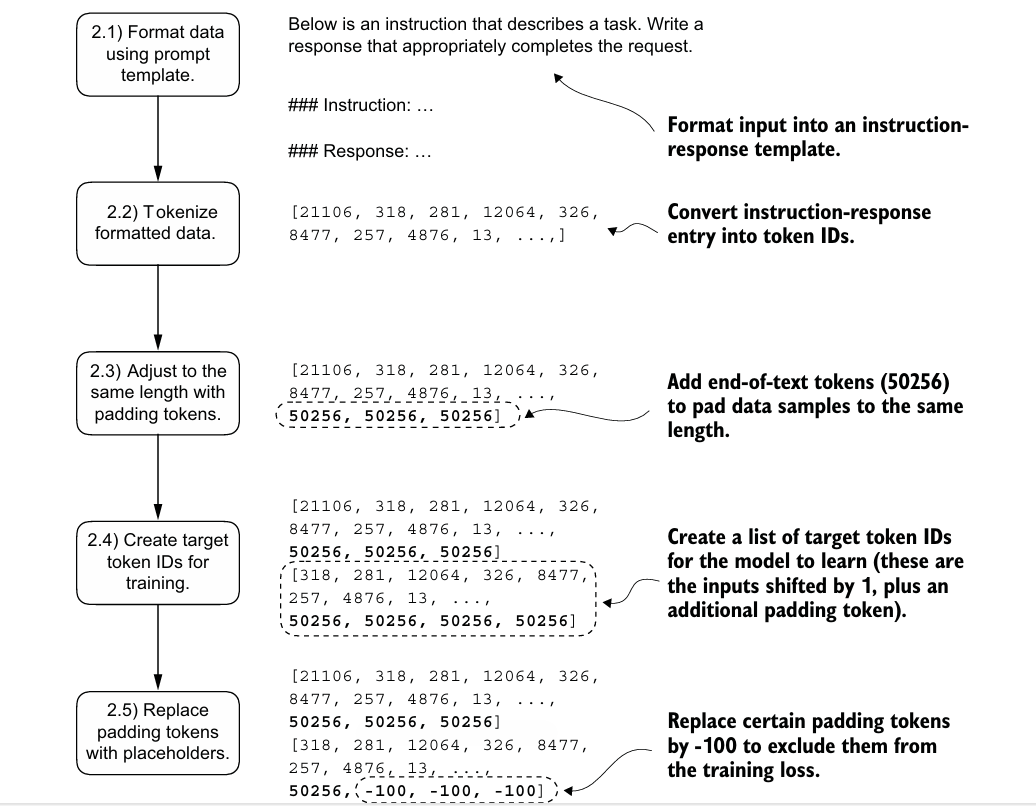

In [7]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []

        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text

            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)


To speed up instruction fine-tuning, multiple examples are grouped into **batches**.
Because prompts have **variable lengths**, batching requires **padding** so all sequences
in a batch share the same length.

For GPT-2, the `<|endoftext|>` token is commonly reused as a padding token.
Instead of appending the string token to raw text, we can directly append its
token ID to pretokenized inputs. Using the GPT-2 tokenizer confirms that the
`<|endoftext|>` token ID is **50256**.

To reduce unnecessary padding, a **custom collate function** is introduced.
It pads sequences **only up to the longest sequence within each batch**, allowing
different batches to have different lengths, which improves efficiency.


In [11]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))


[50256]


We can implement the padding process with a custom collate function:

In [16]:
def custom_collate_draft_1(batch, pad_token_id=50256, device="cpu"):
    # +1 because we will append one extra token before shifting
    batch_max_length = max(len(item) + 1 for item in batch)

    inputs_lst = []
    for item in batch:
        new_item = item.copy()

        # append one pad/eot token (acts like an explicit "end" token)
        new_item += [pad_token_id]

        # pad up to the longest sequence in this batch
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))

        # inputs are everything except the last token (for next-token training)
        inputs = torch.tensor(padded[:-1], dtype=torch.long)
        inputs_lst.append(inputs)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor


In [10]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
    inputs_1,
    inputs_2,
    inputs_3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


### Create target token IDs for training.
Similar to the process we used to pretrain an LLM, the target token IDs match the
input token IDs but are shifted one position to the right.

The following updated collate function generates the target token IDs from the input
token IDs:

In [11]:
def custom_collate_draft_2(batch, pad_token_id=50256, device="cpu"):
    batch_max_length = max(len(item) + 1 for item in batch)

    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )

        inputs = torch.tensor(padded[:-1])   # truncate last token
        targets = torch.tensor(padded[1:])   # shift right by 1

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor


###  Replace padding tokens with placeholders.


In [8]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    batch_max_length = max(len(item) + 1 for item in batch)

    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )

        inputs = torch.tensor(padded[:-1], dtype=torch.long)
        targets = torch.tensor(padded[1:], dtype=torch.long)

        # Replace padding tokens in targets (except the first one) with ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()

        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # Optionally truncate to a maximum length (e.g., GPT-2 context limit)
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor


Again, let’s try the collate function on the sample batch that we created earlier to
check that it works as intended:

In [13]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


<br/>

The purpose of replacing padding tokens in the target sequence with **-100**
is to exclude them from the **cross-entropy loss calculation**.

In PyTorch, target values equal to `-100` are ignored during loss computation.
This ensures that the model is trained only on **meaningful tokens** in the response,
rather than on artificial padding introduced for batching.

At the same time, one end-of-text token (ID 50256) is preserved in the targets,
allowing the model to learn when to properly terminate a generated response.


In [14]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],    
     [-0.5, 1.5]]     
)
targets_1 = torch.tensor([0, 1]) # Correct token indices to generate
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [15]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]     
)

targets_2 = torch.tensor([0, 1, 1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


After adding the third token, the loss value is 0.7936. 
 So far, we have carried out some more or less obvious example calculations using
the cross entropy loss function in PyTorch, the same loss function we used in the
training functions for pretraining and fine-tuning for classification. Now let’s get to
the interesting part and see what happens if we replace the third target token ID
with -100:

In [16]:
targets_3 = torch.tensor([0, 1, -100])
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


### Why we replace padding targets with -100

PyTorch’s `cross_entropy` uses `ignore_index=-100` by default, meaning any target token
equal to **-100 is ignored** during loss computation.

This is why adding an extra target like `-100` does not change the loss:
the loss is computed only over the remaining valid target positions.

In instruction fine-tuning, batching requires padding shorter sequences with the GPT-2
end-of-text token **50256**. However, these additional padding tokens are not meaningful
training signals, so we replace (most) padded target positions with **-100** to exclude them
from the loss. We typically keep **one 50256** in the targets so the model learns when to
terminate a response (end-of-text indicates completion).

It is also common to mask out target tokens corresponding to the **instruction/prompt**
so the loss is computed only on the **response tokens**, encouraging the model to focus on
answer generation rather than memorizing instructions.


### Masking instructions during instruction fine-tuning

At the time of writing, there is **no consensus** on whether masking instruction tokens
during instruction fine-tuning is universally beneficial.

Some approaches mask the instruction tokens so that the **loss is computed only over
the response**, encouraging the model to focus on answer generation rather than
memorizing prompts. However, recent work (e.g., Shi et al., 2024) has shown that
**not masking the instructions** and computing loss over both instructions and responses
can improve LLM performance in certain settings.

In this chapter, we **do not apply instruction masking** and treat it as an optional
experiment for further exploration.


# Creating data loaders for an instruction dataset
### Plugging the dataset and collate function into a DataLoader

After implementing the `InstructionDataset` and a custom `collate_fn`, we can now
connect them directly to PyTorch `DataLoader` objects. The data loaders automatically
shuffle the data and construct batches for instruction fine-tuning.

The custom collate function also moves the input and target tensors to a specified
**device** (CPU, CUDA, or MPS). Performing this device transfer inside the collate
function allows the data loading process to move tensors to the target device
**asynchronously**, reducing GPU blocking inside the training loop.

To reuse the chosen device and configuration, we use Python’s `functools.partial`
to create a version of the collate function with the `device` and
`allowed_max_length=1024` arguments prefilled. This ensures compatibility with
GPT-2’s maximum context length and simplifies DataLoader integration.


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.backends.mps.is_available():  
#     device = torch.device("mps")      
print("Device:", device)


Device: cuda


In [9]:
from functools import partial
customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

Next, we can set up the data loaders as we did previously, but this time, we will use our
custom collate function for the batching process.

In [14]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

Let’s examine the dimensions of the input and target batches generated by the train
ing loader:

In [20]:
print("Train_loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train_loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

The printed shapes show that different batches can have different sequence lengths.
For example, an input and target batch of shape **8 × 61** indicates a batch size of 8,
where each example was padded to 61 tokens, while another batch may be padded to
76 tokens.

This behavior is expected and desirable: thanks to the custom collate function, each
batch is padded only to the **maximum sequence length within that batch**, rather than
to a fixed global length. This reduces unnecessary padding and improves training
efficiency.

With the data loaders in place, we are now ready to load a pretrained LLM and
fine-tune it using these instruction batches.



# Loading a pretrained GPT model for instruction fine-tuning

After preparing the instruction dataset and custom data loaders, the next step is to
load a pretrained language model. Most aspects of instruction fine-tuning are identical
to pretraining and classification fine-tuning, allowing us to reuse the same model
initialization and weight-loading code from earlier chapters.

Instead of the 124M-parameter GPT-2 small model, we load **GPT-2 medium (355M)**.
Smaller models often lack the capacity required to learn the complex and nuanced
patterns needed for high-quality instruction following. The medium-sized model
provides a better balance between capacity and computational feasibility.

Note that loading GPT-2 medium will download approximately **1.42 GB** of model
weights, which is significantly larger than the small model.


In [21]:
from gpt_download import download_and_load_gpt2
from Attention import GPTModel
from Attention import load_weights_into_gpt
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [22]:
CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, 
    models_dir="gpt2"
)
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2\355M\checkpoint
File already exists and is up-to-date: gpt2\355M\encoder.json
File already exists and is up-to-date: gpt2\355M\hparams.json
File already exists and is up-to-date: gpt2\355M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\355M\model.ckpt.index
File already exists and is up-to-date: gpt2\355M\model.ckpt.meta
File already exists and is up-to-date: gpt2\355M\vocab.bpe


### Baseline evaluation of the pretrained model

Before fine-tuning, we evaluate the pretrained LLM on a validation example to establish
a **baseline** for instruction-following performance. This helps us understand how well
the model responds to instructions out of the box and provides a reference point for
measuring the impact of instruction fine-tuning later.

We select the first example from the validation set, format it using the instruction
prompt template, and inspect the resulting input. At this stage, no fine-tuning has
been applied—the model weights remain unchanged.


In [23]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


<br/>

Next we generate the model’s response using the same generate function we used to
pretrain the model in chapter 5

In [1]:
from Attention import generate, text_to_token_ids, token_ids_to_text
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

NameError: name 'model' is not defined

### Extracting the model’s generated response

The `generate` function returns the concatenation of the input prompt and the model’s
generated continuation. While this behavior is convenient for text completion, it is
not ideal for task-specific evaluation.

To isolate the model’s response, we remove the input prompt from the beginning of the
generated text. This allows us to focus solely on the generated answer when comparing
it to the expected response in the dataset.


In [25]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


<br/>

### Baseline result: pretrained model behavior

The pretrained model produces a `Response` section but fails to correctly follow the
instruction. Instead of converting the active sentence to passive voice, it largely
repeats the original input and parts of the instruction.

This behavior highlights a key limitation of pretrained language models: while they
are capable of generating fluent text and mimicking prompt structure, they do not
reliably execute task-specific instructions without additional supervision.

This baseline result motivates the need for instruction fine-tuning, which aims to
teach the model how to properly interpret and respond to human instructions.


# Fine-tuning the LLM on instruction data

With the instruction dataset and custom data loaders in place, we can now fine-tune
the pretrained language model. Instruction fine-tuning uses the same training
infrastructure as pretraining and classification fine-tuning—the key difference lies
in the structure of the data and the target responses.

We reuse the loss computation and training utilities from Chapter 5, specifically
`calc_loss_loader` and `train_model_simple`. Before starting training, we compute
the initial training and validation losses to establish a quantitative baseline.
This allows us to clearly measure the impact of instruction fine-tuning after training.


In [3]:
from Attention import (
    calc_loss_loader,
    train_model_simple
)

Before we begin training, let’s calculate the initial loss for the training and valida
tion sets:

In [27]:
model.to(device)
torch.manual_seed(123)
with torch.no_grad():
    train_loss = calc_loss_loader(
                train_loader, model, device, num_batches=5
                                )
   
    val_loss = calc_loss_loader(
                val_loader, model, device, num_batches=5
                                )
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 0.7618069648742676
Validation loss: 0.7460656642913819


In [28]:
print("device var:", device)
print("model device:", next(model.parameters()).device)


device var: cuda
model device: cuda:0


In [29]:
import time

start_time = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005, weight_decay=0.1
)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context=format_input(val_data[0]),
    tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60

print(f"Training completed in {execution_time_minutes:.2f} minutes.")


Ep 1 (Step 000000): Train loss 0.537, Val loss 0.535
Ep 1 (Step 000005): Train loss 0.231, Val loss 0.250
Ep 1 (Step 000010): Train loss 0.156, Val loss 0.224
Ep 1 (Step 000015): Train loss 0.172, Val loss 0.220
Ep 1 (Step 000020): Train loss 0.139, Val loss 0.216
Ep 1 (Step 000025): Train loss 0.145, Val loss 0.211
Ep 1 (Step 000030): Train loss 0.131, Val loss 0.205
Ep 1 (Step 000035): Train loss 0.186, Val loss 0.198
Ep 1 (Step 000040): Train loss 0.166, Val loss 0.198
Ep 1 (Step 000045): Train loss 0.107, Val loss 0.191
Ep 1 (Step 000050): Train loss 0.100, Val loss 0.188
Ep 1 (Step 000055): Train loss 0.142, Val loss 0.184
Ep 1 (Step 000060): Train loss 0.190, Val loss 0.178
Ep 1 (Step 000065): Train loss 0.127, Val loss 0.177
Ep 1 (Step 000070): Train loss 0.078, Val loss 0.176
Ep 1 (Step 000075): Train loss 0.081, Val loss 0.178
Ep 1 (Step 000080): Train loss 0.134, Val loss 0.179
Ep 1 (Step 000085): Train loss 0.114, Val loss 0.176
Ep 1 (Step 000090): Train loss 0.109, Val loss

### Interpreting training results

The steadily decreasing training and validation losses over two epochs indicate that
the model is learning effectively and improving its ability to follow instructions.
Because both losses decrease together, there is no immediate sign of overfitting.

Qualitative inspection of the generated responses further confirms this improvement:
after fine-tuning, the model correctly converts the active sentence
"The chef cooks the meal every day." into its passive form,
"The meal is cooked every day by the chef."

Since meaningful learning is already observed within two epochs, additional training
may be unnecessary and could even lead to overfitting. To further analyze the learning
dynamics, we next examine the training and validation loss curves using the same
`plot_losses` function employed during pretraining.


In [32]:
from Attention import plot_losses
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

ImportError: cannot import name 'plot_losses' from 'Attention' (C:\Users\Lenovo\Code\LLM\Attention.py)

### Interpreting the loss curves and moving to response evaluation

The loss curves in Figure 7.17 show a substantial improvement in both training and
validation performance over the course of training. The rapid loss reduction during
the initial phase indicates that the model quickly learns meaningful patterns from the
instruction data. As training progresses into the second epoch, the losses continue to
decrease at a slower rate, which is expected as the model refines its representations.

While the loss curves confirm effective optimization, loss values alone are not
sufficient for evaluating instruction-following models. The most critical factor is the
**quality and correctness of the generated responses**. Therefore, the next step is to
extract and store the model’s generated outputs in a structured format that enables
systematic evaluation and comparison against reference responses.


# Extracting and saving model responses

After fine-tuning the language model on the instruction training set, we evaluate its
performance on a held-out test set that was not seen during training. As a first step,
we generate responses for each input in the test dataset and extract only the model’s
generated outputs.

These responses are collected and saved for manual inspection, which is essential for
assessing instruction-following behavior beyond numerical loss values. In the next
step, the extracted responses are evaluated more systematically to quantify their
quality and correctness, as illustrated in Figure 7.18.


In [14]:
torch.manual_seed(123)

for entry in test_data[:3]:
    # 1)  prompt
    input_text = format_input(entry)

    # 2) تولید پاسخ با مدل
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )

    # 3) تبدیل توکن‌ها به متن
    generated_text = token_ids_to_text(token_ids, tokenizer)

    # 4) جدا کردن فقط پاسخ مدل
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )

    # 5) چاپ برای مقایسه
    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text}")
    print("-------------------------------------")


NameError: name 'model' is not defined

In [35]:
save_path = "gpt2_medium_instruction_finetuned.pt"
torch.save(model.state_dict(), save_path)
print("Saved to:", save_path)

Saved to: gpt2_medium_instruction_finetuned.pt


In [15]:
import torch
from Attention import GPTModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768,  "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model = GPTModel(BASE_CONFIG)

model.load_state_dict(
    torch.load("gpt2_medium_instruction_finetuned.pt", map_location=device)
)

model.to(device)
model.eval()
print("Fine-tuned model loaded.")


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4140\2887077932.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("gpt2_medium_instruction_finetuned.pt", map_loca

Fine-tuned model loaded.


In [21]:
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [22]:
next(model.parameters()).device


device(type='cuda', index=0)

In [16]:
from Attention import generate

### Evaluating instruction-following performance

Based on the test set instructions, reference answers, and model-generated responses,
the fine-tuned model performs reasonably well. Some responses are clearly correct,
while others are close but not fully accurate, highlighting the nuanced nature of
instruction-following evaluation.

Unlike classification fine-tuning, where accuracy can be computed directly, evaluating
instruction-tuned LLMs is more complex. In practice, such models are assessed using a
combination of approaches, including short-answer and multiple-choice benchmarks
(e.g., MMLU), human preference comparisons (e.g., LMSYS Chatbot Arena), and
automated conversational evaluations using LLMs as judges (e.g., AlpacaEval).

Since the primary goal is to assess conversational performance rather than isolated
multiple-choice accuracy, human evaluation and automated conversational metrics are
often more informative.


### Conversational performance

Conversational performance refers to an LLM’s ability to engage in human-like dialogue
by understanding context, nuance, and user intent. It goes beyond factual correctness
and includes generating relevant, coherent, and context-aware responses.

Key aspects of conversational performance include maintaining consistency across
turns, adapting to different topics and interaction styles, and producing responses
that align with the user’s underlying intent. As a result, conversational performance
is a central evaluation criterion for instruction-fine-tuned language models, especially
in chatbot and assistant applications.


### Automated evaluation using an LLM-as-judge

While human evaluation provides valuable insights into response quality, it is often
labor-intensive and impractical at scale. Evaluating hundreds or thousands of model
responses manually would require a significant investment of time and effort.

To address this limitation, we adopt an automated evaluation approach inspired by
conversational benchmarks such as AlpacaEval. In this setup, another language model
is used to assess the quality of the fine-tuned model’s responses. Instead of relying on
a public benchmark dataset, we evaluate performance using our own custom test set,
which allows for a more targeted and use-case-specific assessment.

As a preparation step, we generate responses for all test set entries, append the
model-generated responses to the dataset, and save the resulting data to an
`instruction-data-with-response.json` file. This enables efficient reuse and analysis of
the generated responses in future evaluation steps without requiring regeneration.


In [24]:
import json
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )

    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w", encoding="utf-8") as file:
    json.dump(test_data, file, indent=4, ensure_ascii=False)


100%|██████████| 110/110 [01:24<00:00,  1.30it/s]


Let’s verify that the responses have been correctly added to the test_set dictionary
by examining one of the entries:

In [28]:
print(test_data[2])

{'instruction': "Name the author of 'Pride and Prejudice'.", 'input': '', 'output': 'Jane Austen.', 'model_response': "The author of 'Pride and Prejudice' is Jane Austen."}


### Saving the fine-tuned model

After completing instruction fine-tuning, we save the model’s learned parameters for
future reuse. To create a clean and descriptive file name, we remove whitespace and
parentheses from the model identifier and append the `-sft` suffix, which stands for
Supervised Fine-Tuning.

The model is saved using PyTorch’s `state_dict` mechanism, which stores only the
learned weights. This lightweight format allows the model to be easily reloaded later
for inference or further experimentation without retraining.

The saved model can be restored by first re-instantiating the model architecture and
then loading the saved state dictionary.


In [26]:
import re
file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"     
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth


# Automated evaluation of the fine-tuned LLM

Previously, we assessed the instruction-fine-tuned model by manually inspecting a
small number of test set responses. While this provides an initial qualitative signal,
manual evaluation does not scale to large numbers of generated outputs.

To address this limitation, we adopt an automated evaluation strategy in which another,
larger instruction-tuned language model acts as a judge. Specifically, we use an
8-billion-parameter Llama 3 model to evaluate the quality of the fine-tuned model’s
responses across the entire test set.

The Llama 3 model is executed locally using the Ollama application, which provides an
efficient interface for running large language models on a laptop. Ollama is designed
for inference only and does not support training or fine-tuning, making it well suited
for large-scale response evaluation.


In [21]:
from Attention import GPTModel
import torch
from Attention import generate
from Attention import text_to_token_ids, token_ids_to_text
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
import json


with open("instruction-data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion] 
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))


BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768,  "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model = GPTModel(BASE_CONFIG)

def format_input(entry):
    instruction_text = (
                f"Below is an instruction that describes a task. "
                f"Write a response that appropriately completes the request."
                f"\n\n### Instruction:\n{entry['instruction']}"
                        )
   
    input_text = (
                f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
                )
    return instruction_text + input_text

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.load_state_dict(
    torch.load("gpt2-medium355M-sft.pth", map_location=device)
)
model.to(device)
model.eval()

print("Model loaded ✅")


Training set length: 935
Validation set length: 55
Test set length: 110


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17956\1005974572.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("gpt2-medium355M-sft.pth", map_location=device)

Model loaded ✅


In [ ]:
import json

with open("instruction-data-with-response.json", "r", encoding="utf-8") as f:
    test_data = json.load(f)

print("Loaded model responses from disk ✅")

if "model_response" not in test_data[0]:
    print("Generating responses...")
else:
    print("Responses already exist. Skipping generation.")

In [32]:
import psutil
def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running
        
ollama_running = check_if_running("ollama")
if not ollama_running:
    raise RuntimeError(
            "Ollama not running. Launch ollama before proceeding."
                        )
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


# Running the code in a new Python session 
If you already closed your Python session or if you prefer to execute the remaining
code in a different Python session, use the following code, which loads the instruction
and response data file we previously created and redefines the format_input func
tion we used earlier (the tqdm progress bar utility is used later): 

In [ ]:
import json
from tqdm import tqdm
file_path = "instruction-data-with-response.json"
with open(file_path, "r") as file:
    test_data = json.load(file)
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    return instruction_text + input_text

In [43]:
import json
import urllib.request
import urllib.error

def query_model(
    prompt,
    model="llama3:8b",
    url="http://127.0.0.1:11434/api/generate"
):
    data = {
        "model": model,
        "prompt": prompt,
        "stream": True,
        "options": {
            "temperature": 0,
            "num_ctx": 2048
        }
    }

    payload = json.dumps(data).encode("utf-8")

    request = urllib.request.Request(
        url=url,
        data=payload,
        method="POST"
    )
    request.add_header("Content-Type", "application/json")

    result = ""

    try:
        with urllib.request.urlopen(request) as response:
            for raw_line in response:
                line = raw_line.decode("utf-8").strip()
                if not line:
                    continue

                obj = json.loads(line)

                if "response" in obj:
                    result += obj["response"]

                if obj.get("done"):
                    break

    except urllib.error.HTTPError as e:
        error_text = e.read().decode("utf-8", errors="replace")
        raise RuntimeError(f"HTTP {e.code}:\n{error_text}") from e

    return result


# تست
print(query_model("What do Llamas eat?"))


Llamas are herbivores, which means they primarily feed on plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: High-quality hay, such as alfalfa or timothy hay, is a staple in a llama's diet. They enjoy the sweet taste and texture of fresh hay.
3. Grains: Llamas may receive grains like oats, barley, or corn as part of their daily ration. However, it's essential to provide these grains in moderation, as they can be high in calories.
4. Fruits and vegetables: Llamas enjoy a variety of fruits and veggies, such as apples, carrots, sweet potatoes, and leafy greens like kale or spinach.
5. Minerals: Llamas require access to mineral supplements, which help maintain their overall health and well-being.

In the wild, llamas might also eat:

1. Leaves: They'll munch on leaves from trees and shrubs, including plants like willow, alder, and birch.
2. Bark: In some cases, ll

In [44]:
for entry in test_data[:3]:
    prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry['model_response']}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.

Score:
>> I'd rate the model response "The car is as fast as a bullet." an 85 out of 100.

Here's why:

* The response uses a simile correctly, comparing the speed of the car to something else (in this case, a bullet).
* The comparison is relevant and makes sense, as bullets are known for their high velocity.
* The phrase "as fast as" is used correctly to introduce the simile.

The only reason I wouldn't give it a perfect score is that some people might not immediately think of a bullet when they hear "fast", whereas lightning is often an intuitive comparison for speed. However, "a bullet" is still a good choice and effectively conveys the idea that the car is very quick!

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.

<br/>


We evaluate the fine-tuned model using an LLM-as-a-judge approach.
For each test example, we provide the instruction, the ground-truth
output, and the model-generated response to a larger LLM (Llama 3),
which assigns a score from 0 to 100. This enables scalable and
automated evaluation of conversational performance.


The judge model (Llama 3) may produce verbose explanations along with a score.
To compute an average score over the test set, we modify the prompt to request
an integer score only (0–100). We then parse the returned text to extract the
numeric score and aggregate scores across all examples to obtain an overall
quantitative measure of the fine-tuned model’s performance.

In [47]:
def generate_model_scores(json_data, json_key, model="llama3:8b"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
                f"Given the input `{format_input(entry)}` "
                f"and correct output `{entry['output']}`, "
                f"score the model response `{entry[json_key]}`"
                f" on a scale from 0 to 100, where 100 is the best score. "
                f"Respond with the integer number only."  
)
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue
    return scores

In [48]:
scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|██████████| 110/110 [02:17<00:00,  1.25s/it]

Number of scores: 110 of 110
Average score: 50.05

